<a href="https://colab.research.google.com/github/reddyjagadeeshbabu/Jobcheck/blob/main/Milestone_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving fake_job_postings.csv to fake_job_postings (2).csv


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



🔄 Preprocessing data...
✅ Preprocessing complete!

🔄 Training model...
✅ Training complete!

🔄 Testing model...
✅ Testing complete!

📊 Model Evaluation Results:
Accuracy: 0.964765100671141

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      3403
           1       0.98      0.28      0.43       173

    accuracy                           0.96      3576
   macro avg       0.97      0.64      0.71      3576
weighted avg       0.97      0.96      0.96      3576



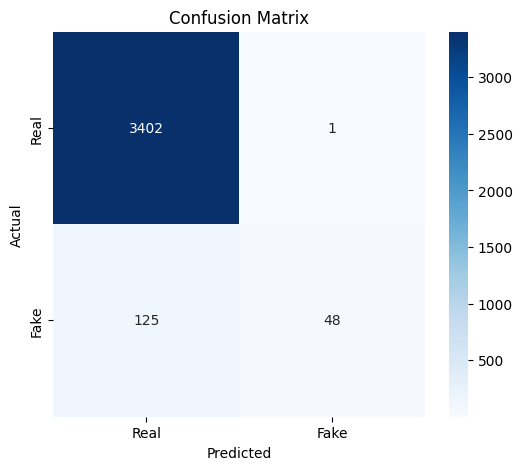


✅ All steps complete! (Preprocessing + Training + Testing)


In [ ]:
from google.colab import files
uploaded = files.upload()

# Install and import libraries
import pandas as pd
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Download NLTK resources (including punkt_tab to fix error)
nltk.download("punkt")
nltk.download("punkt_tab")   # ✅ Fix for LookupError
nltk.download("wordnet")
nltk.download("stopwords")

# Load dataset (make sure the CSV is uploaded in Colab)
df = pd.read_csv("fake_job_postings.csv", encoding="latin-1")

# Function to preprocess text
def preprocess_text(text):
    if pd.isna(text):  # If cell is empty, return empty string
        return ""

    # Lowercase
    text = text.lower()

    # Tokenize
    tokens = word_tokenize(text)

    # Keep only alphabetic words
    tokens = [w for w in tokens if w.isalpha()]

    # Remove stopwords
    stop_words = set(stopwords.words("english"))
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    lems = [lemmatizer.lemmatize(word) for word in tokens]

    # Return as a single string
    return " ".join(lems)

print("\n🔄 Preprocessing data...")
df["description_clean"] = df["description"].apply(preprocess_text)

# Drop rows where target is missing
df = df.dropna(subset=["fraudulent"])  # "fraudulent" is target column (0=real, 1=fake)
print("✅ Preprocessing complete!")

# Features (X) and Target (y)
X = df["description_clean"]
y = df["fraudulent"]

# Convert text into TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print("\n🔄 Training model...")
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("✅ Training complete!")

print("\n🔄 Testing model...")
# Predictions
y_pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("✅ Testing complete!")
print("\n📊 Model Evaluation Results:")
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Save preprocessed dataset
df.to_csv("preprocessed_fake_job_postings.csv", index=False, encoding="utf-8")
print("\n✅ All steps complete! (Preprocessing + Training + Testing)")


In [ ]:
from google.colab import files
uploaded = files.upload()

# Import libraries
import pandas as pd
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Download NLTK resources
nltk.download("punkt")
nltk.download("punkt_tab")   # ✅ Fix LookupError
nltk.download("wordnet")
nltk.download("stopwords")

# Load dataset
df = pd.read_csv("fake_job_postings.csv", encoding="latin-1")

# Function to preprocess text
def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w.isalpha()]
    stop_words = set(stopwords.words("english"))
    tokens = [word for word in tokens if word not in stop_words]
    lemmatizer = WordNetLemmatizer()
    lems = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(lems)

print("\n🔄 Preprocessing data...")
df["description_clean"] = df["description"].apply(preprocess_text)
df = df.dropna(subset=["fraudulent"])  # Drop rows with missing target
print("✅ Preprocessing complete!")

# Show first 5 preprocessed rows
print("\n📊 First 5 Preprocessed Rows:")
print(df[["title", "description", "description_clean"]].head(5))

# Features (X) and Target (y)
X = df["description_clean"]
y = df["fraudulent"]

# Convert text into TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print("\n🔄 Training model...")
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("✅ Training complete!")

print("\n🔄 Testing model...")
y_pred = model.predict(X_test)
print("✅ Testing complete!")

# Show first 5 actual vs predicted results
results = pd.DataFrame({
    "Job Title": df.loc[y_test.index, "title"].values[:5],
    "Actual": y_test.values[:5],
    "Predicted": y_pred[:5]
})

print("\n📊 First 5 Test Results:")
print(results.to_string(index=False))

print("\n✅ All steps complete! (Preprocessing + Training + Testing)")


Saving fake_job_postings.csv to fake_job_postings (5).csv


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



🔄 Preprocessing data...
✅ Preprocessing complete!

📊 First 5 Preprocessed Rows:
                                       title  \
0                           Marketing Intern   
1  Customer Service - Cloud Video Production   
2    Commissioning Machinery Assistant (CMA)   
3          Account Executive - Washington DC   
4                        Bill Review Manager   

                                         description  \
0  Food52, a fast-growing, James Beard Award-winn...   
1  Organised - Focused - Vibrant - Awesome!Do you...   
2  Our client, located in Houston, is actively se...   
3  THE COMPANY: ESRI â Environmental Systems Re...   
4  JOB TITLE: Itemization Review ManagerLOCATION:...   

                                   description_clean  
0  james beard online food community curated reci...  
1  organised focused vibrant awesome passion cust...  
2  client located houston actively seeking experi...  
3  company esri environmental system research ins...  
4  job title itemi